# Notebook 01c — Feature Engineering & TCI Merge

## README

### Overview

This notebook takes the wide-format panel CSVs produced by `01b` and:

1. Optionally creates a **1-day lagged NO₂ feature** (`no2_lag1`) per `(city, spatial_id)` group. Rows that cannot have a lag (first day of each city's date range) are dropped.
2. Merges the **Traffic Congestion Index (TCI)** from `processed/{city}/tci/{city}_tci_2025.csv` into the panel. Rows with no matching TCI are dropped (inner join on `spatial_id` × `date`).
3. Reports **missingness** introduced at each step so the user understands data loss.

### Inputs (per city)

| Source | Path | Notes |
|---|---|---|
| `01b_raster_to_grid_aggregation.ipynb` | `data/processed/{city}/grid_panel/{city}_grid_panel.csv.gz` | Wide panel (no2, era5_temp, …) |
| World Bank | `data/processed/{city}/tci/{city}_tci_2025.csv` | Columns: `date`, `spatial_id`, `length` (→ renamed `tci`) |

### Output (per city)

```
data/processed/{city}/grid_panel/
  {city}_modelling_panel.csv.gz    ← panel + tci [+ no2_lag1]
```

### Output schema

```
city | spatial_id | date | no2 | era5_temp | [no2_lag1] | tci
```

### Pipeline position

```
01b_raster_to_grid_aggregation.ipynb
  └─► 01c_feature_engineering.ipynb  ◄── YOU ARE HERE
        └─► 01d_monthly_tile_panel.ipynb
```

### Design principles

- **City-agnostic**: add cities by appending to `CITIES`.
- **Transparent data loss**: every step that drops rows reports counts and percentages.
- **Lag is optional**: controlled by `ADD_NO2_LAG` flag; set to `False` to skip entirely.
- **Inner join on TCI**: rows without a matching TCI observation are dropped — the dependent variable must be present for modelling.


## Part 0 — Environment Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore", category=FutureWarning)

print("Libraries loaded.")

Libraries loaded.


## Part 1 — USER INPUTS

**Only edit this cell** to configure cities and feature options.

In [2]:
# =============================================================================
# ██████████████████████   USER INPUTS   ██████████████████████
# =============================================================================

# --- Project root and data directory ---
PROJECT_ROOT = Path().resolve().parent
DATA_ROOT    = PROJECT_ROOT / "data"

# --- Cities to process ---
CITIES = [
    # {"name": "abuja",        "display_name": "Abuja"},
    # {"name": "algiers",      "display_name": "Algiers"},
    {"name": "baghdad",      "display_name": "Baghdad"},
    {"name": "buenos_aires", "display_name": "Buenos Aires"},
    # {"name": "cairo",        "display_name": "Cairo"},
    # {"name": "cape_town",    "display_name": "Cape Town"},
    # {"name": "dakar",        "display_name": "Dakar"},
    # {"name": "lima",         "display_name": "Lima"},
    # {"name": "los_angeles",  "display_name": "Los Angeles"},
    # {"name": "madrid",       "display_name": "Madrid"},
    {"name": "mexico_city",  "display_name": "Mexico City"},
    # {"name": "mumbai",       "display_name": "Mumbai"},
    {"name": "new_york",     "display_name": "New York"},
    # {"name": "santiago",     "display_name": "Santiago"},
    # {"name": "yangon",       "display_name": "Yangon"},
]

# --- Feature options ---
ADD_NO2_LAG = False   # True → create no2_lag1 column (1-day lag per spatial_id)
                     # Rows that cannot have a lag (first date per city) are dropped.

# --- TCI source column name (will be renamed to 'tci') ---
TCI_SOURCE_COL = "length"

# =============================================================================
# END OF USER INPUTS
# =============================================================================

print(f"Cities    : {[c['name'] for c in CITIES]}")
print(f"NO2 lag   : {ADD_NO2_LAG}")

Cities    : ['baghdad', 'buenos_aires', 'mexico_city', 'new_york']
NO2 lag   : False


## Part 2 — Helper Functions

In [3]:
def load_panel(city_name: str) -> pd.DataFrame:
    """Load the 01b grid panel CSV (gzip or plain) for a city."""
    panel_dir = DATA_ROOT / "processed" / city_name / "grid_panel"

    # Accept both compressed and plain CSV
    for fname in [f"{city_name}_grid_panel.csv.gz", f"{city_name}_grid_panel.csv"]:
        p = panel_dir / fname
        if p.exists():
            df = pd.read_csv(p, parse_dates=["date"])
            print(f"  Loaded panel : {fname}  ({len(df):,} rows)")
            return df

    raise FileNotFoundError(f"No panel CSV found in {panel_dir}")


def load_tci(city_name: str) -> pd.DataFrame:
    """Load the TCI CSV for a city and rename 'length' → 'tci'."""
    tci_path = DATA_ROOT / "processed" / city_name / "tci" / f"{city_name}_tci_2025.csv"
    if not tci_path.exists():
        raise FileNotFoundError(f"TCI file not found: {tci_path}")

    tci = pd.read_csv(tci_path, parse_dates=["date"])
    tci = tci.rename(columns={TCI_SOURCE_COL: "tci"})

    # Keep only the columns needed for the merge
    tci = tci[["date", "spatial_id", "tci"]].drop_duplicates()
    print(f"  Loaded TCI   : {tci_path.name}  ({len(tci):,} rows, "
          f"{tci['date'].nunique()} dates × {tci['spatial_id'].nunique()} cells)")
    return tci


def add_no2_lag(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create a 1-day lagged NO₂ feature (no2_lag1) per (city, spatial_id).

    The lag is computed by sorting on date within each group and shifting by 1.
    Rows where no2_lag1 is NaN (i.e. the first date of each group) are dropped.
    Returns the DataFrame with the new column appended before 'tci' (if present).
    """
    df = df.sort_values(["city", "spatial_id", "date"]).copy()
    df["no2_lag1"] = (
        df.groupby(["city", "spatial_id"])["no2"]
          .shift(1)
    )
    return df


def report_step(label: str, n_before: int, n_after: int, total: int):
    """Print a one-line data-loss report for a processing step."""
    dropped = n_before - n_after
    pct_dropped  = 100 * dropped  / n_before if n_before else 0
    pct_retained = 100 * n_after  / total    if total    else 0
    print(f"  {label:<35} "
          f"dropped {dropped:>8,} rows ({pct_dropped:4.1f}%)  "
          f"→ {n_after:>8,} rows retained ({pct_retained:.1f}% of original)")


print("Helper functions defined.")

Helper functions defined.


## Part 3 — Pre-flight Checks

Verify that both the panel and TCI files exist for each city.

In [4]:
print("=" * 60)
print("PRE-FLIGHT CHECKS")
print("=" * 60)

all_ok = True

for city in CITIES:
    city_name = city["name"]
    print(f"\n📍 {city['display_name']} ({city_name})")

    # Panel
    panel_dir = DATA_ROOT / "processed" / city_name / "grid_panel"
    panel_found = any(
        (panel_dir / f"{city_name}_grid_panel{ext}").exists()
        for ext in [".csv.gz", ".csv"]
    )
    print(f"  Panel CSV  [{'✓' if panel_found else '✗ MISSING'}]: {panel_dir}")
    if not panel_found:
        all_ok = False

    # TCI
    tci_path = DATA_ROOT / "processed" / city_name / "tci" / f"{city_name}_tci_2025.csv"
    tci_found = tci_path.exists()
    print(f"  TCI CSV    [{'✓' if tci_found else '✗ MISSING'}]: {tci_path}")
    if not tci_found:
        all_ok = False

print()
if all_ok:
    print("✅ All checks passed.")
else:
    print("⚠️  Some inputs are missing — check paths above before proceeding.")

PRE-FLIGHT CHECKS

📍 Baghdad (baghdad)
  Panel CSV  [✓]: /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/baghdad/grid_panel
  TCI CSV    [✓]: /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/baghdad/tci/baghdad_tci_2025.csv

📍 Buenos Aires (buenos_aires)
  Panel CSV  [✓]: /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/buenos_aires/grid_panel
  TCI CSV    [✓]: /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/buenos_aires/tci/buenos_aires_tci_2025.csv

📍 Mexico City (mexico_city)
  Panel CSV  [✓]: /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/mexico_city/grid_panel
  TCI CSV    [✓]: /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/mexico_ci

## Part 4 — Feature Engineering & TCI Merge

For each city:
1. Load the 01b panel.
2. Optionally add the NO₂ lag feature and drop lag-less rows.
3. Merge TCI (inner join — rows without a TCI match are dropped).
4. Report data loss at each step.

In [7]:
city_modelling_panels: dict = {}  # city_name → final DataFrame
city_n_original: dict = {}

for city in CITIES:
    city_name    = city["name"]
    display_name = city["display_name"]

    print("\n" + "=" * 60)
    print(f"{display_name} ({city_name})")
    print("=" * 60)

    # --- Load inputs ---------------------------------------------------------
    try:
        panel = load_panel(city_name)
        tci   = load_tci(city_name)
    except FileNotFoundError as e:
        print(f"  ✗ Skipping — {e}")
        continue

    n_original = len(panel)
    city_n_original[city_name] = n_original
    print(f"  Original panel: {n_original:,} rows  "
          f"({panel['date'].nunique()} dates × {panel['spatial_id'].nunique()} cells)")

    # --- spatial_id overlap check --------------------------------------------
    panel_ids = set(panel["spatial_id"].unique())
    tci_ids   = set(tci["spatial_id"].unique())
    overlap   = len(panel_ids & tci_ids)
    print(f"  spatial_id overlap : {overlap:,} / {len(tci_ids):,} TCI cells "
          f"({100 * overlap / len(tci_ids):.1f}%)")

    # --- Step 1: NO₂ lag feature ---------------------------------------------
    if ADD_NO2_LAG:
        if "no2" not in panel.columns:
            print("  ⚠️  ADD_NO2_LAG is True but 'no2' column not found — skipping lag.")
        else:
            panel = panel.sort_values(["city", "spatial_id", "date"]).copy()

            # Shift by 1 row within each (city, spatial_id) group
            panel["no2_lag1"] = panel.groupby(["city", "spatial_id"])["no2"].shift(1)

            # Nullify lag where the previous row is not exactly 1 calendar day prior
            # — prevents cross-interval contamination when date ranges are non-consecutive
            prev_date = panel.groupby(["city", "spatial_id"])["date"].shift(1)
            not_consecutive = (panel["date"] - prev_date) != pd.Timedelta("1D")
            panel.loc[not_consecutive, "no2_lag1"] = np.nan

            n_before_lag_drop = len(panel)
            panel = panel.dropna(subset=["no2_lag1"]).reset_index(drop=True)
            report_step("NO₂ lag — dropped non-consecutive/first-date rows",
                        n_before_lag_drop, len(panel), n_original)
    else:
        print("  [no2_lag1] Skipped (ADD_NO2_LAG = False)")

    n_after_lag = len(panel)

    # --- Step 2: Merge TCI (inner join) --------------------------------------
    panel = panel.merge(
        tci[["date", "spatial_id", "tci"]],
        on=["date", "spatial_id"],
        how="inner",   # drops rows with no matching TCI observation
    )
    report_step("TCI merge — unmatched rows dropped",
                n_after_lag, len(panel), n_original)

    # --- Final sort ----------------------------------------------------------
    panel = panel.sort_values(["spatial_id", "date"]).reset_index(drop=True)
    city_modelling_panels[city_name] = panel

    print(f"  ✓ Final panel : {len(panel):,} rows  "
          f"({panel['date'].nunique()} dates × {panel['spatial_id'].nunique()} cells)")
    print(f"  Columns       : {list(panel.columns)}")

print("\n✅ Feature engineering complete.")


Baghdad (baghdad)
  Loaded panel : baghdad_grid_panel.csv.gz  (1,980,490 rows)
  Loaded TCI   : baghdad_tci_2025.csv  (729,306 rows, 352 dates × 4302 cells)
  Original panel: 1,980,490 rows  (365 dates × 5426 cells)
  spatial_id overlap : 4,302 / 4,302 TCI cells (100.0%)
  [no2_lag1] Skipped (ADD_NO2_LAG = False)
  TCI merge — unmatched rows dropped  dropped 1,253,215 rows (63.3%)  →  727,275 rows retained (36.7% of original)
  ✓ Final panel : 727,275 rows  (351 dates × 4302 cells)
  Columns       : ['city', 'date', 'spatial_id', 'no2', 'era5_temp', 'tci']

Buenos Aires (buenos_aires)


KeyboardInterrupt: 

## Part 5 — Missingness Summary

Overview of total data loss across all cities and a per-variable NaN audit of the final panels.

In [ ]:
print("=" * 60)
print("MISSINGNESS SUMMARY")
print("=" * 60)

# --- Overall retention per city ---
print(f"\n{'City':<15} {'Original':>10} {'Final':>10} {'Dropped':>10} {'Retained %':>12}")
print("-" * 60)
for city_name, panel in city_modelling_panels.items():
    city_cfg = next(c for c in CITIES if c["name"] == city_name)
    n_orig   = city_n_original[city_name]
    n_final  = len(panel)
    dropped  = n_orig - n_final
    pct      = 100 * n_final / n_orig
    print(f"{city_cfg['display_name']:<15} {n_orig:>10,} {n_final:>10,} {dropped:>10,} {pct:>11.1f}%")

# --- Per-variable NaN audit ---
print(f"\n{'City':<15} {'Column':<12} {'NaN rows':>10} {'NaN %':>8}")
print("-" * 50)
for city_name, panel in city_modelling_panels.items():
    for col in panel.columns:
        if col in ["city", "spatial_id", "date"]:
            continue
        n_nan = panel[col].isna().sum()
        pct   = 100 * n_nan / len(panel)
        print(f"{city_name:<15} {col:<12} {n_nan:>10,} {pct:>7.1f}%")

MISSINGNESS SUMMARY

City              Original      Final    Dropped   Retained %
------------------------------------------------------------
Baghdad          1,980,490    727,275  1,253,215        36.7%
Buenos Aires     5,185,190    946,671  4,238,519        18.3%
Mexico City      2,945,185  1,118,931  1,826,254        38.0%
New York         2,223,130  1,629,109    594,021        73.3%

City            Column         NaN rows    NaN %
--------------------------------------------------
baghdad         no2             101,522    14.0%
baghdad         era5_temp             0     0.0%
baghdad         tci                   0     0.0%
buenos_aires    no2             334,410    35.3%
buenos_aires    era5_temp           840     0.1%
buenos_aires    tci                   0     0.0%
mexico_city     no2             480,584    43.0%
mexico_city     era5_temp             0     0.0%
mexico_city     tci                   0     0.0%
new_york        no2             644,647    39.6%
new_york        e

## Part 6 — Diagnostic Plots

### 6.1 TCI time series — city-mean daily TCI

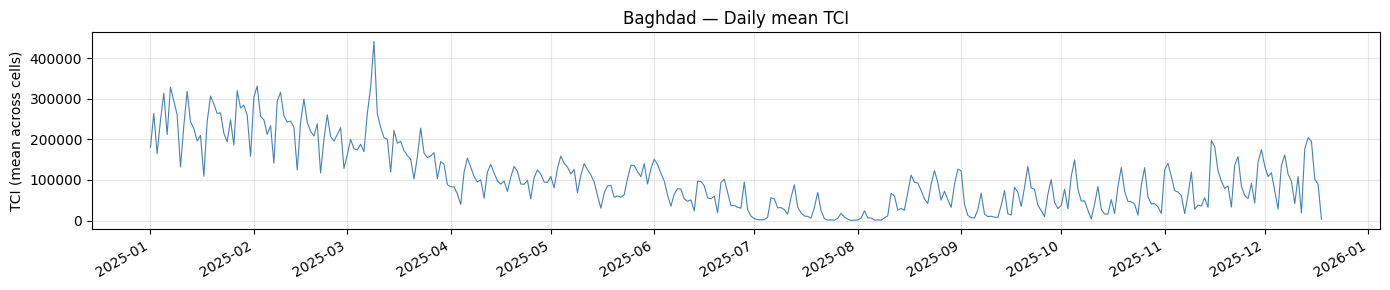

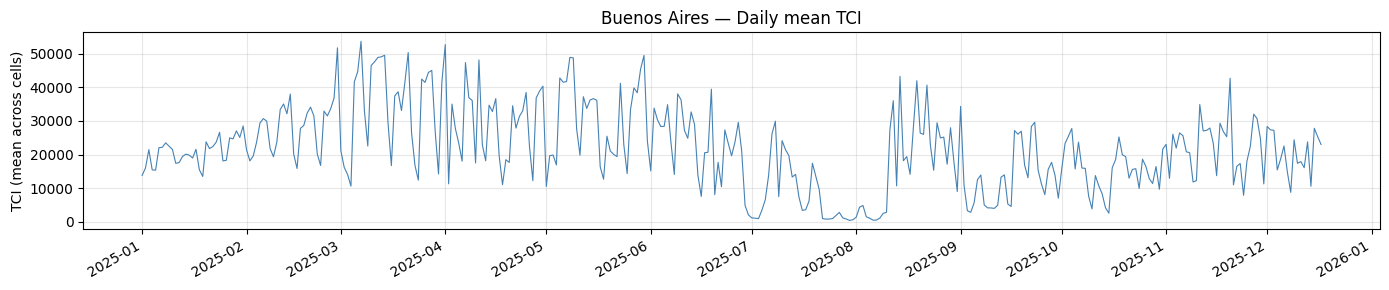

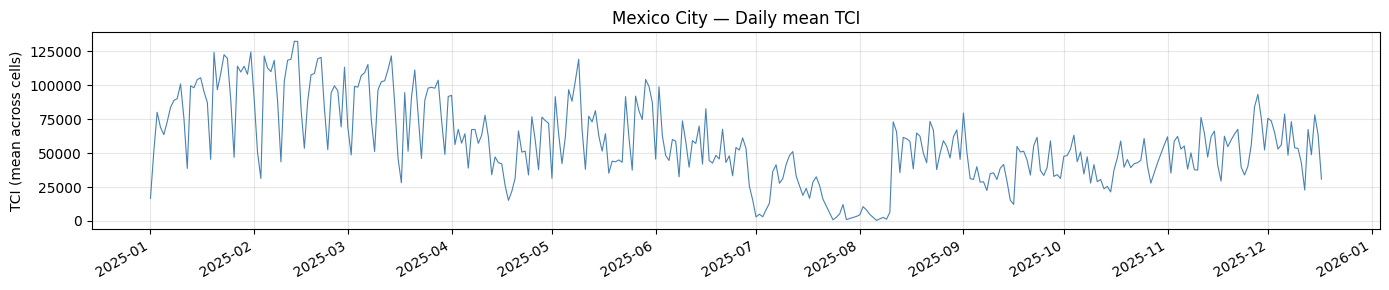

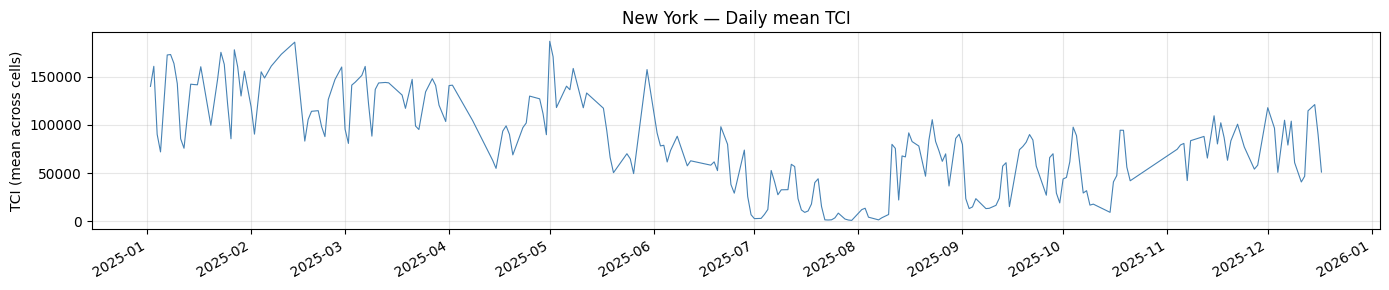

In [ ]:
for city_name, panel in city_modelling_panels.items():
    city_cfg   = next((c for c in CITIES if c["name"] == city_name), {})
    daily_mean = panel.groupby("date")["tci"].mean()

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(daily_mean.index, daily_mean.values, linewidth=0.8, color="steelblue")
    ax.set_title(f"{city_cfg.get('display_name', city_name)} — Daily mean TCI", fontsize=12)
    ax.set_ylabel("TCI (mean across cells)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

### 6.2 NO₂ vs NO₂ lag scatter (sample of cells)

In [ ]:
if ADD_NO2_LAG:
    for city_name, panel in city_modelling_panels.items():
        city_cfg = next((c for c in CITIES if c["name"] == city_name), {})

        if "no2_lag1" not in panel.columns:
            continue

        # Sample up to 5000 rows for readability
        sample = panel[["no2", "no2_lag1"]].dropna().sample(
            min(5000, len(panel)), random_state=42
        )

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(sample["no2_lag1"], sample["no2"],
                   alpha=0.1, s=5, color="steelblue")
        ax.set_xlabel("no2_lag1 (t-1)")
        ax.set_ylabel("no2 (t)")
        ax.set_title(f"{city_cfg.get('display_name', city_name)} — NO₂ vs lag", fontsize=11)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("ADD_NO2_LAG is False — scatter plot skipped.")

ADD_NO2_LAG is False — scatter plot skipped.


## Part 7 — Save Outputs

In [ ]:
for city_name, panel in city_modelling_panels.items():
    out_dir = DATA_ROOT / "processed" / city_name / "grid_panel"
    out_dir.mkdir(parents=True, exist_ok=True)

    # Serialise: ensure date is string, categoricals are strings
    panel_out = panel.copy()
    panel_out["date"] = panel_out["date"].astype(str)
    for col in panel_out.select_dtypes(include="category").columns:
        panel_out[col] = panel_out[col].astype(str)

    # Save as gzip-compressed CSV
    out_path = out_dir / f"{city_name}_modelling_panel.csv.gz"
    panel_out.to_csv(out_path, index=False, compression="gzip")
    size_mb = out_path.stat().st_size / 1e6
    print(f"  {city_name}: {out_path.name}  ({size_mb:.1f} MB, {len(panel):,} rows)")

print("\n✅ All outputs saved.")

  baghdad: baghdad_modelling_panel.csv.gz  (18.4 MB, 727,275 rows)
  buenos_aires: buenos_aires_modelling_panel.csv.gz  (25.2 MB, 946,671 rows)
  mexico_city: mexico_city_modelling_panel.csv.gz  (27.3 MB, 1,118,931 rows)
  new_york: new_york_modelling_panel.csv.gz  (31.9 MB, 1,629,109 rows)

✅ All outputs saved.


## Part 8 — Summary

In [ ]:
print("=" * 60)
print("NOTEBOOK 01c SUMMARY")
print("=" * 60)

for city_name, panel in city_modelling_panels.items():
    city_cfg = next((c for c in CITIES if c["name"] == city_name), {})
    out_path = DATA_ROOT / "processed" / city_name / "grid_panel" / f"{city_name}_modelling_panel.csv.gz"
    size     = f"{out_path.stat().st_size / 1e6:.1f} MB" if out_path.exists() else "not found"

    print(f"\n{city_cfg.get('display_name', city_name)}")
    print(f"  Rows         : {len(panel):,}")
    print(f"  Grid cells   : {panel['spatial_id'].nunique():,}")
    print(f"  Dates        : {panel['date'].nunique()}  "
          f"({panel['date'].min()} \u2192 {panel['date'].max()})")
    print(f"  Columns      : {list(panel.columns)}")
    print(f"  NO₂ lag      : {'yes' if 'no2_lag1' in panel.columns else 'no'}")
    print(f"  Output       : {out_path.name}  ({size})")

print("\n\u2192 Next step: 02_panel_assembly.ipynb")

NOTEBOOK 01c SUMMARY

Baghdad
  Rows         : 727,275
  Grid cells   : 4,302
  Dates        : 351  (2025-01-01 00:00:00 → 2025-12-18 00:00:00)
  Columns      : ['city', 'date', 'spatial_id', 'no2', 'era5_temp', 'tci']
  NO₂ lag      : no
  Output       : baghdad_modelling_panel.csv.gz  (18.4 MB)

Buenos Aires
  Rows         : 946,671
  Grid cells   : 4,264
  Dates        : 351  (2025-01-01 00:00:00 → 2025-12-17 00:00:00)
  Columns      : ['city', 'date', 'spatial_id', 'no2', 'era5_temp', 'tci']
  NO₂ lag      : no
  Output       : buenos_aires_modelling_panel.csv.gz  (25.2 MB)

Mexico City
  Rows         : 1,118,931
  Grid cells   : 5,649
  Dates        : 345  (2025-01-01 00:00:00 → 2025-12-17 00:00:00)
  Columns      : ['city', 'date', 'spatial_id', 'no2', 'era5_temp', 'tci']
  NO₂ lag      : no
  Output       : mexico_city_modelling_panel.csv.gz  (27.3 MB)

New York
  Rows         : 1,629,109
  Grid cells   : 7,832
  Dates        : 236  (2025-01-02 00:00:00 → 2025-12-17 00:00:00)
  